<a href="https://colab.research.google.com/github/DineshSBhauryal/streamlit-app/blob/main/Session_10_RAG_Part_2_PDFs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import nltk
from nltk import word_tokenize
from nltk import sent_tokenize

from nltk import pos_tag
from nltk.tag.mapping import map_tag

import numpy as np

nltk.download('all', quiet=True)

True

In [ ]:
def get_upos_tags(text: str):
    """
    Tokenizes the text and returns (word, UPOS) pairs.
    Example UPOS tags: NOUN, VERB, ADJ, DET, ADP, etc.
    """
    word_list = word_tokenize(text)
    treebank_tags = pos_tag(word_list)
    upos_tags = [(word, map_tag('en-ptb', 'universal', tag)) for word, tag in treebank_tags]
    return upos_tags

In [ ]:
# Install the Sentence Transformer library
!pip install --quiet --upgrade sentence-transformers

import os
import logging

# Suppress Hugging Face / Transformers logs
os.environ["TRANSFORMERS_VERBOSITY"] = "error"  # only show errors

logging.getLogger("transformers").setLevel(logging.ERROR)
logging.getLogger("sentence_transformers").setLevel(logging.ERROR)

from sentence_transformers import SentenceTransformer, util

# Load model silently
model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 588.9/588.9 kB 11.4 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
def get_embedding(text):
    return model.encode(text,convert_to_tensor=True)

def find_text_similarity(text1, text2):
    return round(float(util.pytorch_cos_sim(get_embedding(text1), get_embedding(text2))[0][0]), 4)

def find_embedding_similarity(emb1, emb2):
    return round(float(util.pytorch_cos_sim(emb1, emb2)[0][0]), 4)

In [ ]:
def create_embedding_list(text_list):
    return [get_embedding(text) for text in text_list]

In [ ]:
def find_answer(query, text_list, embedding_list):
    query_embedding = get_embedding(query)
    sim_list = [find_embedding_similarity(query_embedding, emb) for emb in embedding_list]
    print("Similarity values between query and all sentences in the list:")
    print(sim_list)
    print("")
    return text_list[sim_list.index(max(sim_list))]

In [ ]:
def find_answer_top_k(query, text_list, embedding_list, k=2):
    query_embedding = get_embedding(query)
    sim_list = [find_embedding_similarity(query_embedding, emb) for emb in embedding_list]

    # Get indices of top-k similarities (sorted descending)
    top_k_indices = np.argsort(sim_list)[::-1][:k]

    # Return top-k texts as a list
    return [text_list[i] for i in top_k_indices]


In [ ]:
from openai import OpenAI

from dotenv import load_dotenv
import os
load_dotenv("api_key.env")
api_key = os.getenv('api_key')

# 1. Visit : https://openrouter.ai/
# 2. Login with your Gmail ID and create a new API Key (top right menu)
# 3. Create api_key.env file in the same folder as your code
# 4. Put the api_key there. Just write one line (use your own API Key, the one below wont work):
# api_key=sk-or-v1-aasdewr34asdc0r31oweijf

def get_ai_response(prompt):
  client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=api_key,
  )

  completion = client.chat.completions.create(
      model="openai/gpt-oss-20b:free",
    messages=[
      {
        "role": "user",
        "content": prompt
      }
    ]
  )

  return completion.choices[0].message.content


# Chatting with PDFs

References:

https://unstructured.io

https://www.youtube.com/watch?v=uLrReyH5cu0

https://docs.unstructured.io/open-source/core-functionality/chunking

In [ ]:
!pip install -Uq "unstructured[all-docs]" pillow lxml pillow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 18.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 43.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.4/109.4 kB 11.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.4/68.4 kB 6.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 647.0 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 118.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 32.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.7/107.7 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 35.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━

In [ ]:
!apt-get install -y poppler-utils

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  poppler-utils
0 upgraded, 1 newly installed, 0 to remove and 1 not upgraded.
Need to get 186 kB of archives.
After this operation, 697 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 poppler-utils amd64 22.02.0-2ubuntu0.12 [186 kB]
Fetched 186 kB in 0s (2,201 kB/s)
Selecting previously unselected package poppler-utils.
(Reading database ... 118212 files and directories currently installed.)
Preparing to unpack .../poppler-utils_22.02.0-2ubuntu0.12_amd64.deb ...
Unpacking poppler-utils (22.02.0-2ubuntu0.12) ...
Setting up poppler-utils (22.02.0-2ubuntu0.12) ...
Processing triggers for man-db (2.10.2-1) ...


In [ ]:

import requests

# Download the PDF locally
url = "https://arxiv.org/pdf/2008.07779"
file_path = "paper.pdf"
with open(file_path, "wb") as f:
    f.write(requests.get(url).content)

In [ ]:

from unstructured.partition.pdf import partition_pdf

chunks = partition_pdf(
    filename=file_path,
    infer_table_structure=True,            # extract tables
    strategy="hi_res",                     # mandatory to infer tables

    extract_image_block_types=["Image", "Table"],   # Add 'Table' to list to extract image of tables
    # image_output_dir_path=output_path,   # if None, images and tables will saved in base64

    extract_image_block_to_payload=True,   # if true, will extract base64 for API usage

    chunking_strategy="by_title",          # or 'basic'
    max_characters=10000,                  # defaults to 500
    combine_text_under_n_chars=2000,       # defaults to 0
    new_after_n_chars=6000,

    # extract_images_in_pdf=True,          # deprecated
)

yolox_l0.05.onnx:   0%|          | 0.00/217M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/274 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/115M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/367 [00:00<?, ?it/s]

In [ ]:
chunks[0].__dict__

{'text': '0\n\n2020\n\n2\n\n0\n\n2\n\ng u A 8 1 ] G L . s c [ 1 v 9 7 7 7 0 . 8 0 0 2\n\n:\n\nv\n\narX1V\n\ni\n\nX\n\nr\n\na\n\nPredicting Future Sales of Retail Products using Machine Learning\n\nDevendra Swami\n\nAlay Dilipbhai Shah\n\nMS, Computer Science University of Southern California Los Angeles, CA 90007 dswami@usc.edu\n\nMS, Computer Science University of Southern California Los Angeles, CA 90007 alaydili@usc.edu\n\nSubhrajeet K B Ray\n\nMS, Computer Science University of Southern California Los Angeles, CA 90007 skray@usc.edu\n\nAbstract\n\nTechniques for making future predictions based upon the present and past data, has always been an area with direct application to various real life problems. We are discussing a similar problem in this paper. The problem statement is provided by Kaggle, which also serves as an ongoing competition on the Kaggle platform. In this project, we worked with a challenging time-series dataset consisting of daily sales data, kindly provided by one

Multi-modal AI

Its an adaptation of the original transformer model to take care of non-tex data inputs.

For processing PDFs, we need to extract text, tables and images. Process text like the normal RAG pipeline. But for tables and images, we need to feed it to multi-modal AI to get a text summary of the contents. And then use this text summary in our RAG pipeline.

# Extract Tables

In [ ]:
chunk_tables = []
for chunk in chunks:
    elements = chunk.metadata.orig_elements
    chunk_tables.extend([el for el in elements if 'Table' in str(type(el))])
chunk_tables

In [ ]:
chunk_tables[0].__dict__

{'text': 'Parameters Description Optimal Value eta Learning Rate 0.148 max_depth Maximum depth of the tree 6 min_child_weight Minimum sum of weight of observation in a child 26 lambda L2 regularization term on weights 0.171 alpha L1 regularization term on weights 0.170',
 'embeddings': None,
 '_element_id': None,
 'metadata': <unstructured.documents.elements.ElementMetadata at 0x7871346e5e80>}

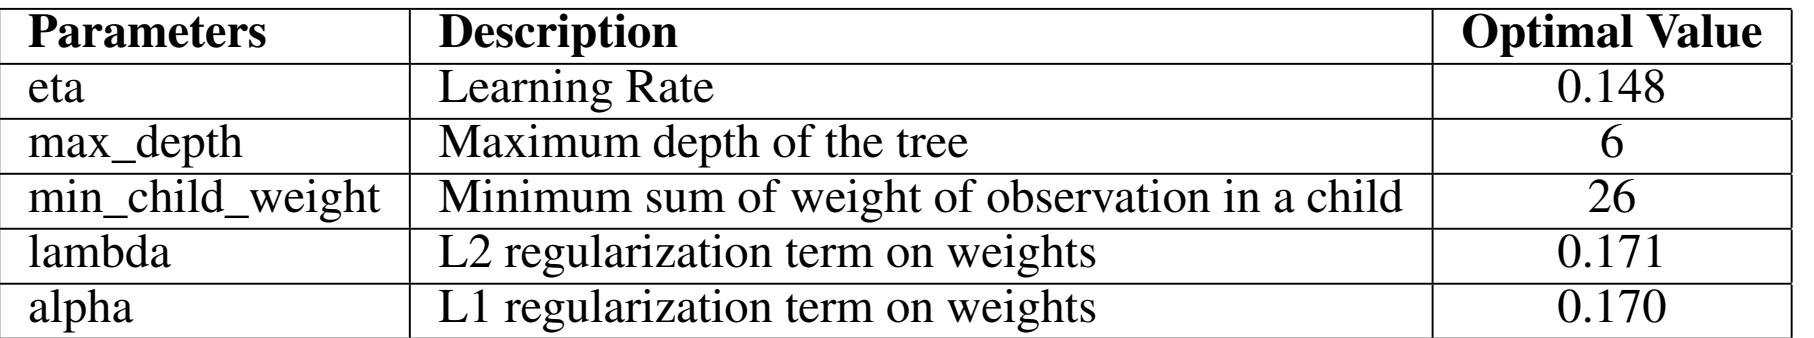

In [ ]:
import base64
from io import BytesIO
from PIL import Image

img_data = base64.b64decode(chunk_tables[0].metadata.image_base64)
img = Image.open(BytesIO(img_data))
display(img)

# For tables, you need to first generate a summary of the table.
# Along with that, you need to attach the actual data in markdown format.

# Extract Images

In [ ]:
# chunk_images = []
# for chunk in chunks:
#     elements = chunk.metadata.orig_elements
#     chunk_images.extend([el for el in elements if 'Image' in str(type(el))])
# chunk_images

In [ ]:
# Get the images from the CompositeElement objects
def get_images_base64(chunks):
    images_b64 = []
    for chunk in chunks:
        if "CompositeElement" in str(type(chunk)):
            chunk_els = chunk.metadata.orig_elements
            for el in chunk_els:
                if "Image" in str(type(el)):
                    images_b64.append(el.metadata.image_base64)
    return images_b64

images = get_images_base64(chunks)

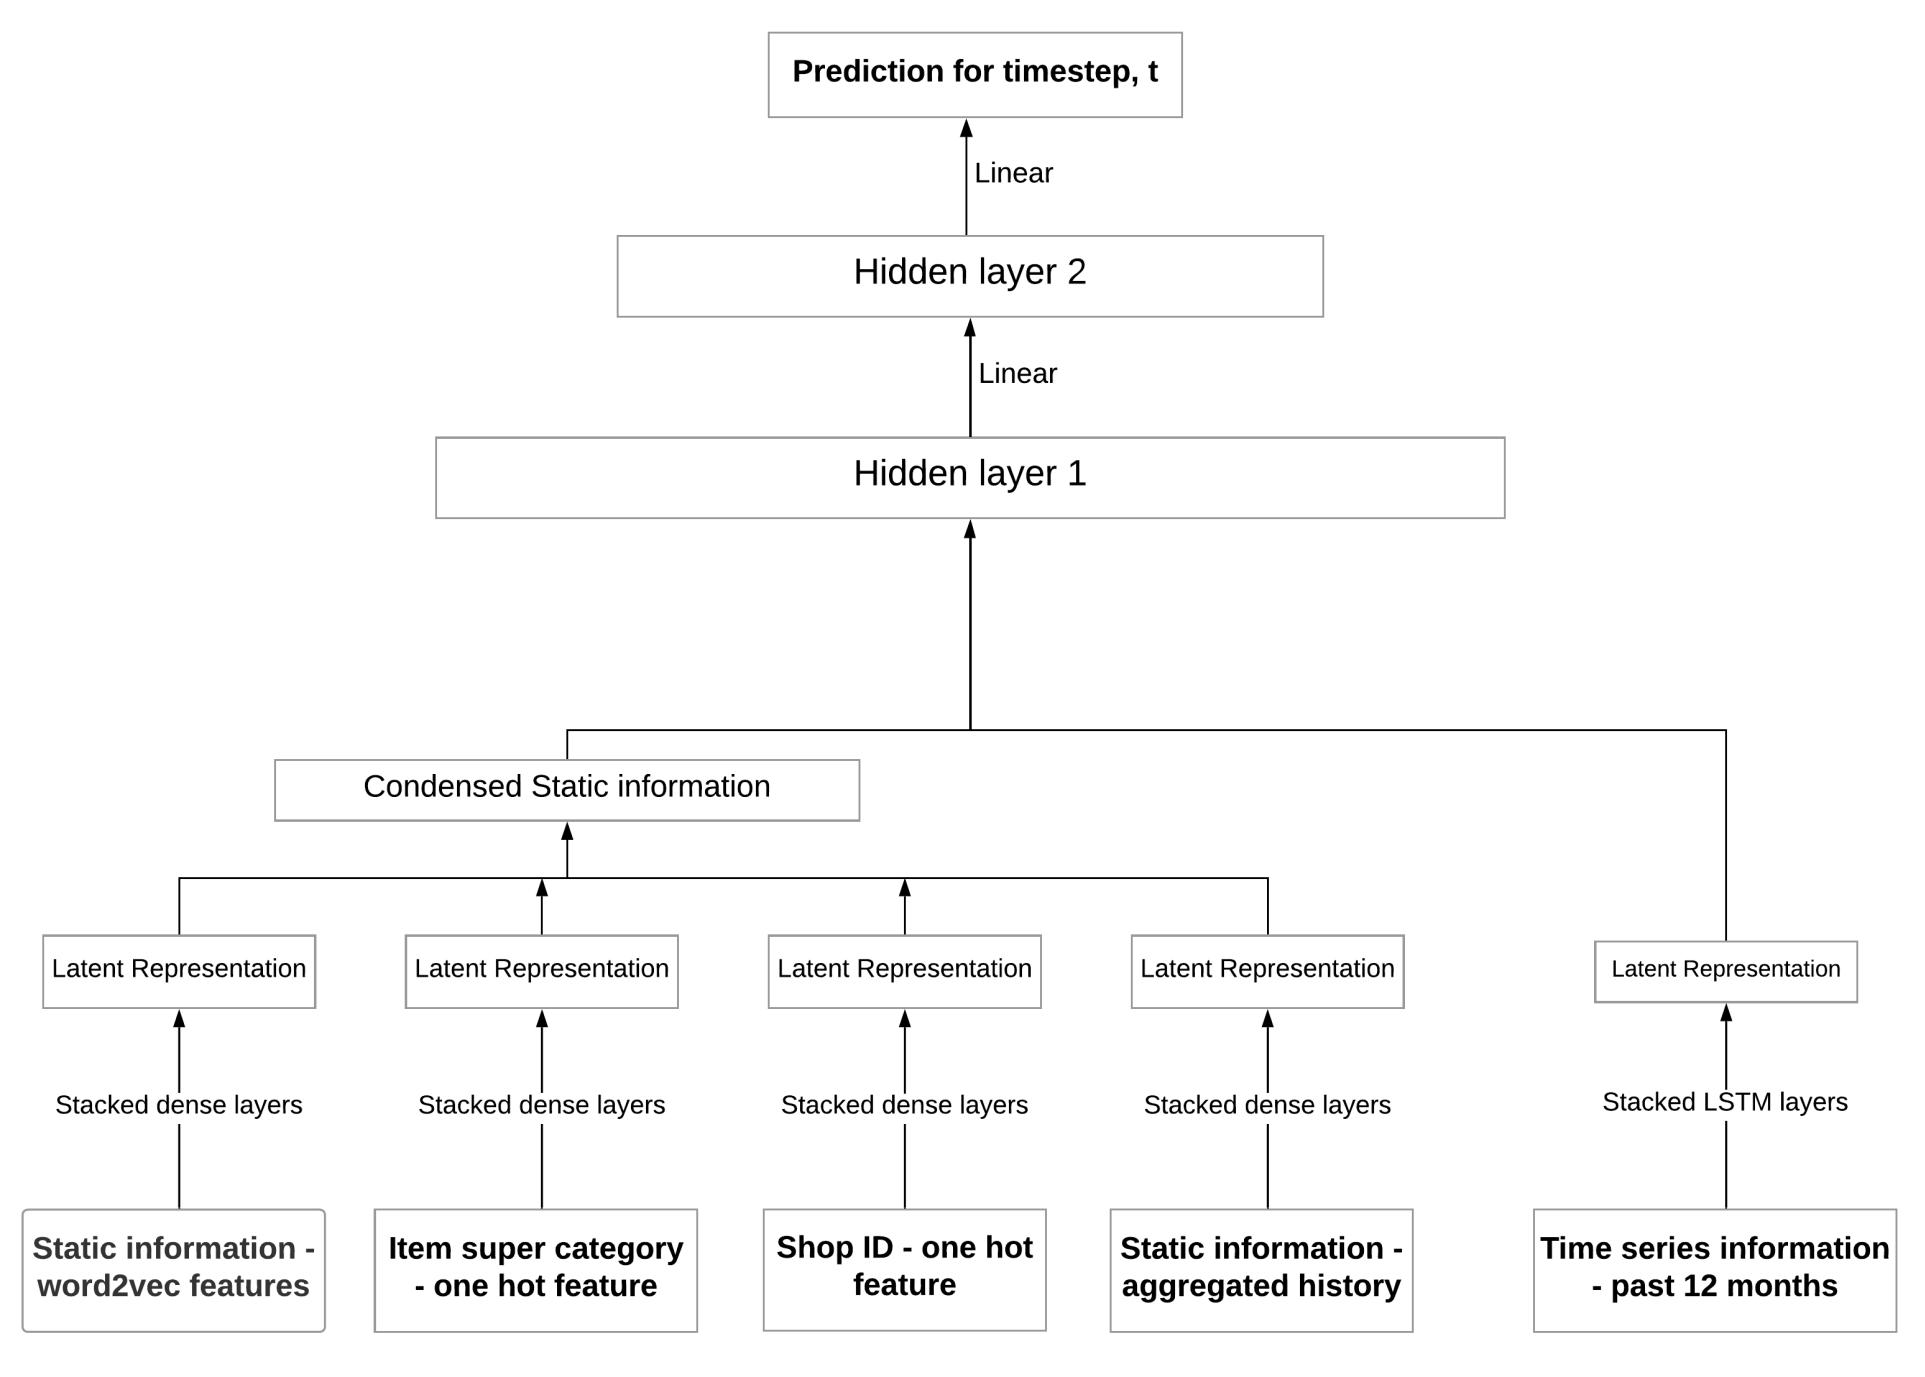

In [ ]:
import base64
from IPython.display import Image, display

def display_base64_image(base64_code):
    # Decode the base64 string to binary
    image_data = base64.b64decode(base64_code)
    # Display the image
    display(Image(data=image_data))

display_base64_image(images[0])

In [ ]:
# AI models are for answering generic questions.

# We use RAG because AI models do not have all the answers.


# Why do we need AI agents?

# When we need to do reasoning.
# Lets say a company has many tasks which can be automated.
# And you have build AI systems for all these tasks.
# And I need AI agents to reason and plan and execute suitable AI pipelines.
# There are two approaches to this.
# One is fully automated (Eg. CrewAI)
# One is using our own algo (Eg. LangGraph)
